# **1. Descripción del Problema**

**Problema:** El desafío que estamos abordando consiste en clasificar reseñas de productos de Amazon como positivas (1) o negativas (0) únicamente a partir del texto que los usuarios escriben. Esto entra dentro del área de análisis de sentimientos, que básicamente trata de que la máquina “entienda” cómo se siente una persona según lo que escribe. Es un problema interesante porque, aunque a simple vista parezca fácil, el lenguaje humano es muy ambiguo y puede expresar emociones de formas muy sutiles, con sarcasmo, ironía o palabras que dependen mucho del contexto.

**Objetivo:** La idea principal es construir un modelo que pueda predecir el sentimiento de una reseña, aprendiendo de ejemplos anteriores y captando patrones en el texto que indiquen si la opinión es positiva o negativa. Con esto buscamos poder automatizar el análisis de comentarios de usuarios, de manera que podamos entender de forma rápida y confiable qué piensan los clientes sobre un producto. Además, este modelo servirá como base para agregar predicciones de nuevas reseñas que se quieran evaluar manualmente o en tiempo real.

# **2. Carga y Exploración Inicial (EDA)**

In [15]:
import kagglehub

# Descarga la última versión del dataset de Kaggle
path = kagglehub.dataset_download("bittlingmayer/amazonreviews")

# Imprime la ruta donde se encuentran descargados los archivos del dataset
print("Path to dataset files:", path)

Path to dataset files: C:\Users\salom\.cache\kagglehub\datasets\bittlingmayer\amazonreviews\versions\7


In [16]:
# Como Kagglehub descarga los archivos en una carpeta oculta dentro del caché de usuario, 
# vamos a copiarlos a una ubicación más accesible para su análisis.

import shutil
import os

# Ruta donde Kagglehub guarda los archivos descargados
origen_path = r"C:\Users\salom\.cache\kagglehub\datasets\bittlingmayer\amazonreviews\versions\7"

# Ruta destino donde queremos copiar los archivos
destino_path = r"C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset"

# Copiar todos los archivos del origen al destino
for archivo in os.listdir(origen_path):
    ruta_origen = os.path.join(origen_path, archivo)
    ruta_destino = os.path.join(destino_path, archivo)
    if os.path.isfile(ruta_origen):
        shutil.copy2(ruta_origen, ruta_destino)

print("Archivos copiados exitosamente a:", destino_path)


Archivos copiados exitosamente a: C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset


In [17]:
# Vamos a explorar el contenido de los archivos .bz2 descargados y listar algunas líneas de ejemplo.

import bz2
import os

# Iterar por los archivos .bz2
for archivo in os.listdir(destino_path):
    if archivo.endswith(".bz2"):
        ruta_completa = os.path.join(destino_path, archivo)
        print(f"\n=== Contenido de {archivo} ===")
        
        # Abrir el archivo y leer algunas líneas
        with bz2.open(ruta_completa, "rt", encoding="utf-8") as f:
            for i, linea in enumerate(f):
                print(linea.strip())
                if i >= 4:  # Mostrar solo las primeras 5 líneas
                    break


print("\nDIMENSIONES INICIALES DE LOS ARCHIVOS .BZ2")

for archivo in os.listdir(destino_path):
    if archivo.endswith(".bz2"):
        ruta_completa = os.path.join(destino_path, archivo)
        
        # Contar el número total de líneas en cada archivo
        with bz2.open(ruta_completa, "rt", encoding="utf-8") as f:
            total_lineas = sum(1 for linea in f)
            
        # Obtener el tamaño del archivo comprimido
        tamaño_bytes = os.path.getsize(ruta_completa)
        tamaño_mb = tamaño_bytes / (1024 * 1024)
        
        print(f"\nArchivo: {archivo}")
        print(f"Número total de reseñas: {total_lineas:,}")
        print(f"Tamaño del archivo comprimido: {tamaño_mb:.2f} MB")
        print(f"Tamaño en bytes: {tamaño_bytes:,}")



=== Contenido de test.ft.txt.bz2 ===
__label__2 Great CD: My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I'm in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kill. One of life's hidden gems. This is a desert isle CD in my book. Why she never made it big is just beyond me. Everytime I play this, no matter black, white, young, old, male, female EVERYBODY says one thing "Who was that singing ?"
__label__2 One of the best game music soundtracks - for a game I didn't really play: Despite the fact that I have only played a small portion of the game, the music I heard (plus the connection to Chrono Trigger which was great as well) led me to purchase the soundtrack, and it remains one of my favorite albums. There is an incredible mix of fun, epic, and emotional songs. Those sad and beautiful tracks I especial

Como podemos observar, los tamaños son bastante grandes, por lo que trabajaremos con una muestra representativa del dataset completo para facilitar el análisis y procesamiento de los datos.

Adicional, se realia la revisión para definir que tipo de sentimiendo es __label__1 y __label__2 y en este casi se define que:
- __label__1 -> **Negativo (0)**
- __label__2 -> **Positivo (1)**

In [18]:
# Ahora procedemos con el análisis de datos utilizando pandas, numpy, matplotlib, seaborn, y nltk.

import bz2
import pandas as pd
import nltk

# Descargar recursos NLTK 
nltk.download('stopwords')
nltk.download('punkt')

# Función para leer y parsear archivos .bz2
def extraer_datos_bz2(file_path, sample_size=50000): # Aqupi se define el tamaño de la muestra dado el dataset tan grande

    # Listas para almacenar los datos
    reviews = []
    labels = []
    
    # En el ejercicio inicial se usó un enfoque incorrecto para abrir archivos bz2, por lo tanto, con el try-except se maneja cualquier error.
    try:
        print(f"Intentando abrir: {file_path}")
        print("Archivo abierto correctamente.")
        
        # Abrir el archivo bz2 correctamente
        with bz2.open(file_path, 'rt', encoding='utf-8') as file:
            for i, line in enumerate(file):
                if i >= sample_size:
                    break
                    
                # Mostrar progreso cada 10,000 líneas para monitorear el avance
                if i % 10000 == 0 and i > 0:
                    print(f"Procesadas {i} líneas...")
                
                # Parsear la línea (formato: __label__1 o __label__2)
                if line.startswith('__label__1'):
                    labels.append(0)  # Negativo
                    reviews.append(line[len('__label__1 '):].strip())
                elif line.startswith('__label__2'):
                    labels.append(1)  # Positivo
                    reviews.append(line[len('__label__2 '):].strip())
        
        # Confirmar el número de reseñas procesadas
        print(f"Procesamiento completado: {len(reviews)} reseñas")
        print("\n")
        
    except Exception as e:
        print(f"Error: {e}")
        return None
    
    # Crear DataFrame
    return pd.DataFrame({'review_text': reviews, 'sentiment': labels})

# Mensaje para indicar que se están cargando los datos y que el proceso hasta ahora es correcto
print("\n")
print("Cargando datos con rutas correctas...")
print("\n")

# Definir la ruta base donde se encuentran los archivos
base_path = r"C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset"

# Rutas completas a los archivos de entrenamiento y prueba
train_path = os.path.join(base_path, "train.ft.txt.bz2")
test_path = os.path.join(base_path, "test.ft.txt.bz2")

# Cargar dataset de entrenamiento
df_train = extraer_datos_bz2(train_path, sample_size=50000)

# Cargar dataset de prueba  
df_test = extraer_datos_bz2(test_path, sample_size=10000)

# Verificar que se cargó correctamente el dataset de entrenamiento
if df_train is not None:
    print(f"Distribución de sentimientos en train:")
    print(df_train['sentiment'].value_counts())
else:
    print("Error cargando train")

# Verificar que se cargó correctamente el dataset de prueba
if df_test is not None:
    print(f"Distribución de sentimientos en test:")
    print(df_test['sentiment'].value_counts())
else:
    print("Error cargando test")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\salom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\salom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!




Cargando datos con rutas correctas...


Intentando abrir: C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset\train.ft.txt.bz2
Archivo abierto correctamente.
Procesadas 10000 líneas...
Procesadas 20000 líneas...
Procesadas 30000 líneas...
Procesadas 40000 líneas...
Procesamiento completado: 50000 reseñas


Intentando abrir: C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset\test.ft.txt.bz2
Archivo abierto correctamente.
Procesamiento completado: 10000 reseñas


Distribución de sentimientos en train:
sentiment
1    25506
0    24494
Name: count, dtype: int64
Distribución de sentimientos en test:
sentiment
1    5125
0    4875
Name: count, dtype: int64


=== ANÁLISIS DEL DATASET DE ENTRENAMIENTO ===
Dimensiones del dataset de entrenamiento: (50000, 2)


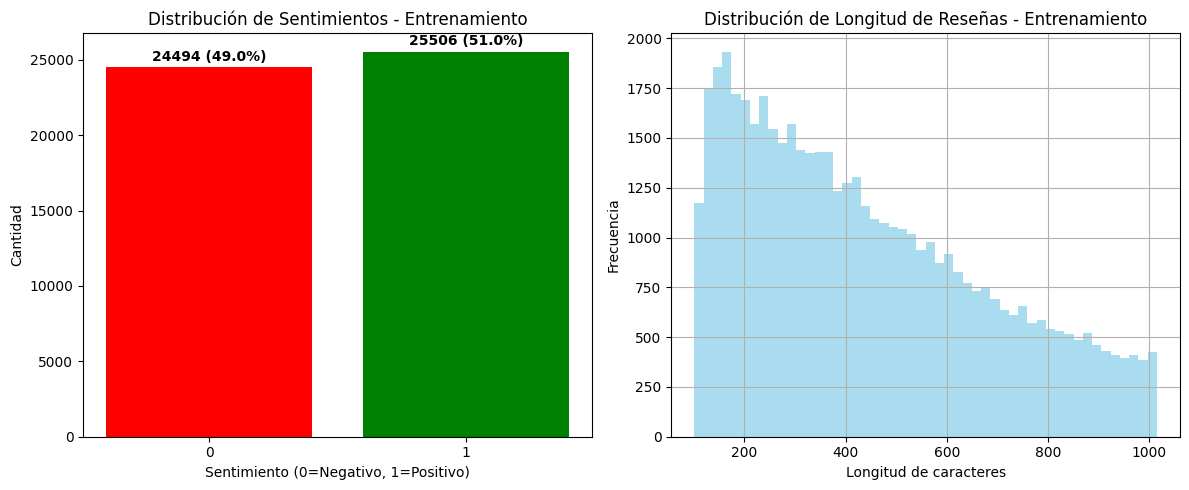

Longitud promedio de reseñas (Entrenamiento): 441.02 caracteres
Longitud máxima (Entrenamiento): 1015 caracteres
Longitud mínima (Entrenamiento): 101 caracteres


=== ANÁLISIS DEL DATASET DE PRUEBA ===
Dimensiones del dataset de prueba: (10000, 2)


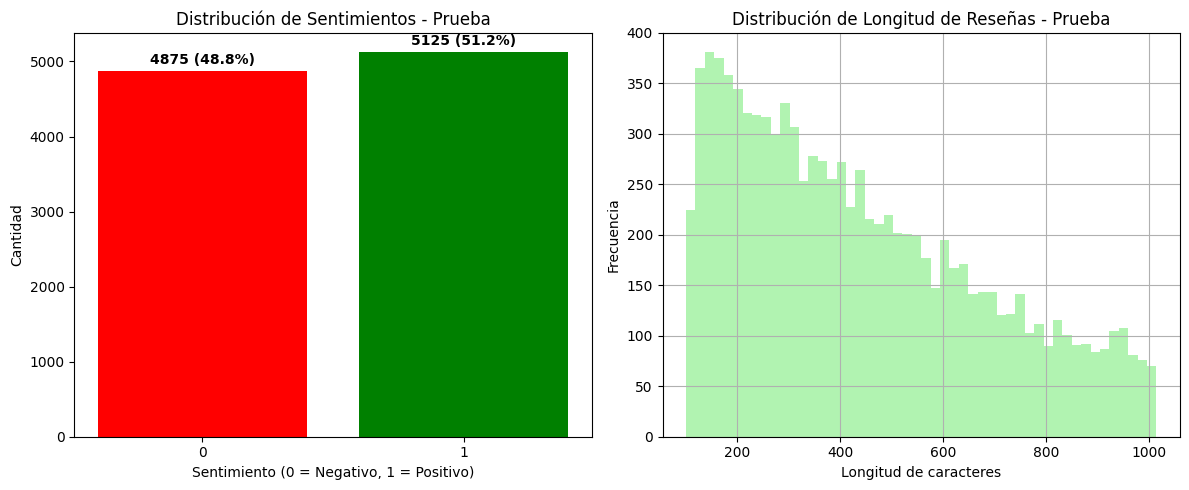

Longitud promedio de reseñas (Prueba): 440.06 caracteres
Longitud máxima (Prueba): 1015 caracteres
Longitud mínima (Prueba): 101 caracteres


In [19]:
import matplotlib.pyplot as plt

# Vamos a analizar ambos datasets por separado: entrenamiento y prueba.

# Análisis del dataset de entrenamiento
print("=== ANÁLISIS DEL DATASET DE ENTRENAMIENTO ===")
print(f"Dimensiones del dataset de entrenamiento: {df_train.shape}")

plt.figure(figsize=(12, 5))

# Subplot 1: Distribución de sentimientos (Entrenamiento)
plt.subplot(1, 2, 1)
sent_counts_train = df_train['sentiment'].value_counts().sort_index()
sent_percent_train = (sent_counts_train / len(df_train)) * 100

bars_train = plt.bar(sent_counts_train.index.astype(str), sent_counts_train.values, color=['red', 'green'])
plt.title('Distribución de Sentimientos - Entrenamiento')
plt.xlabel('Sentimiento (0=Negativo, 1=Positivo)')
plt.ylabel('Cantidad')

# Etiquetas de cantidad y porcentaje
for i, bar in enumerate(bars_train):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height + (len(df_train) * 0.005),
        f"{sent_counts_train.iloc[i]} ({sent_percent_train.iloc[i]:.1f}%)", 
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Subplot 2: Longitud de reseñas (Entrenamiento)
df_train['review_length'] = df_train['review_text'].str.len()
plt.subplot(1, 2, 2)
df_train['review_length'].hist(bins=50, alpha=0.7, color='skyblue')
plt.title('Distribución de Longitud de Reseñas - Entrenamiento')
plt.xlabel('Longitud de caracteres')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Estadísticas (Entrenamiento)
print(f"Longitud promedio de reseñas (Entrenamiento): {df_train['review_length'].mean():.2f} caracteres")
print(f"Longitud máxima (Entrenamiento): {df_train['review_length'].max()} caracteres")
print(f"Longitud mínima (Entrenamiento): {df_train['review_length'].min()} caracteres")
print("\n")

# --- Análisis del dataset de prueba ---
print("=== ANÁLISIS DEL DATASET DE PRUEBA ===")
print(f"Dimensiones del dataset de prueba: {df_test.shape}")

plt.figure(figsize=(12, 5))

# Subplot 1: Distribución de sentimientos (Prueba)
plt.subplot(1, 2, 1)
sent_counts_test = df_test['sentiment'].value_counts().sort_index()
sent_percent_test = (sent_counts_test / len(df_test)) * 100

bars_test = plt.bar(sent_counts_test.index.astype(str), sent_counts_test.values, color=['red', 'green'])
plt.title('Distribución de Sentimientos - Prueba')
plt.xlabel('Sentimiento (0 = Negativo, 1 = Positivo)')
plt.ylabel('Cantidad')

# Etiquetas con cantidad y porcentaje
for i, bar in enumerate(bars_test):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height + (len(df_test) * 0.005),
        f"{sent_counts_test.iloc[i]} ({sent_percent_test.iloc[i]:.1f}%)", 
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Subplot 2: Longitud de reseñas (Prueba)
df_test['review_length'] = df_test['review_text'].str.len()
plt.subplot(1, 2, 2)
df_test['review_length'].hist(bins=50, alpha=0.7, color='lightgreen')
plt.title('Distribución de Longitud de Reseñas - Prueba')
plt.xlabel('Longitud de caracteres')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Estadísticas (Prueba)
print(f"Longitud promedio de reseñas (Prueba): {df_test['review_length'].mean():.2f} caracteres")
print(f"Longitud máxima (Prueba): {df_test['review_length'].max()} caracteres")
print(f"Longitud mínima (Prueba): {df_test['review_length'].min()} caracteres")


# **3. Preprocesamiento de Texto**

In [20]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer, WordNetLemmatizer

# Descargar recursos NLTK necesarios
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')  # Mejora la precisión de lematización

# Configuración de herramientas de preprocesamiento
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")
lemmatizer = WordNetLemmatizer()

# preprocesamiento de texto optimizado
def preprocesar_texto_para_modelo(text):

    # Verificar si el texto es una cadena válida
    if not isinstance(text, str):
        return ""

    # Convertir a minúsculas
    text = text.lower()

    # Eliminar caracteres especiales, números y signos
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenizar (dividir por espacios)
    tokens = text.split()
    
    # Remover stopwords y aplicar lematización + stemming
    cleaned_tokens = []
    for word in tokens:
        if word not in stop_words and len(word) > 2:
            lemma = lemmatizer.lemmatize(word)
            stemmed = stemmer.stem(lemma)
            cleaned_tokens.append(stemmed)
    
    return ' '.join(cleaned_tokens)

# Procesar ambos datasets
print("Preprocesando texto de entrenamiento...")
x_train = df_train['review_text']
y_train = df_train['sentiment']
x_train_cleaned = x_train.apply(preprocesar_texto_para_modelo)

print("Preprocesando texto de test...")
x_test = df_test['review_text']
y_test = df_test['sentiment']
x_test_cleaned = x_test.apply(preprocesar_texto_para_modelo)

# Verificar ejemplos de texto original y preprocesado
print("\nEjemplo de texto original (train):")
print(x_train.sample(3, random_state=42).values)

print("\nEjemplo de texto preprocesado (train):")
print(x_train_cleaned.sample(3, random_state=42).values)


Preprocesando texto de entrenamiento...


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\salom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\salom\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\salom\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Preprocesando texto de test...

Ejemplo de texto original (train):
["Every woman should buy this book!: Ever since my mother was diagnosed with breast cancer I have read almost anything I can get my hands on regarding this dreadful disease. This book is by far the most outstanding I have read. I wish I had looked here first. Joseph Keon's 7-step plan is remarkable and so very easy to read. I've read it from cover to cover 3 or 4 times and have tried almost all of the recipes he suggests. They are just fantastic. I've watched my weight and exercised regularly most of my life....now I feel that, with his help, I'm on the right track with nutrition, too. If only we all would follow his advice, maybe there would be less people having to deal with breast cancer. I highly recommend reading this book."
 "Worst dubbing ever!: Fast beat motivating music. Average workout. But the dubbing is so bad as to be comically distracting. Might be better if you speak German, but with English dubbing, it's

# **4. Vectorización TF-IDF**

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Crear y configurar el vectorizador
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,    # límite de características para reducir dimensionalidad
    ngram_range=(1, 2),    # considera unigramas y bigramas
    min_df=5,              # ignora términos que aparecen en menos de 5 documentos
    max_df=0.8,            # ignora términos que aparecen en más del 80% de los documentos
    stop_words='english'   # elimina stopwords en inglés
)

# Ajustar el vectorizador con los datos LIMPIOS de entrenamiento
x_train_tfidf = tfidf_vectorizer.fit_transform(x_train_cleaned)

# Transformar el conjunto de prueba con el mismo vocabulario
x_test_tfidf = tfidf_vectorizer.transform(x_test_cleaned)

# Resultados de la vectorización
print("\nDimensiones de la matriz TF-IDF:")
print(f"  • Train: {x_train_tfidf.shape}")
print(f"  • Test:  {x_test_tfidf.shape}")

# Mostrar una muestra del vocabulario aprendido
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nEjemplo de 20 características del vocabulario:")
print(feature_names[:20])



Dimensiones de la matriz TF-IDF:
  • Train: (50000, 10000)
  • Test:  (10000, 10000)

Ejemplo de 20 características del vocabulario:
['abandon' 'abbey' 'abil' 'abl' 'abl make' 'abl play' 'abl read' 'abl use'
 'abl watch' 'abomin' 'abort' 'abound' 'abridg' 'abridg version' 'abrupt'
 'absenc' 'absent' 'absolut' 'absolut amaz' 'absolut best']


# **5. WordCloud para Análisis Exploratorio**

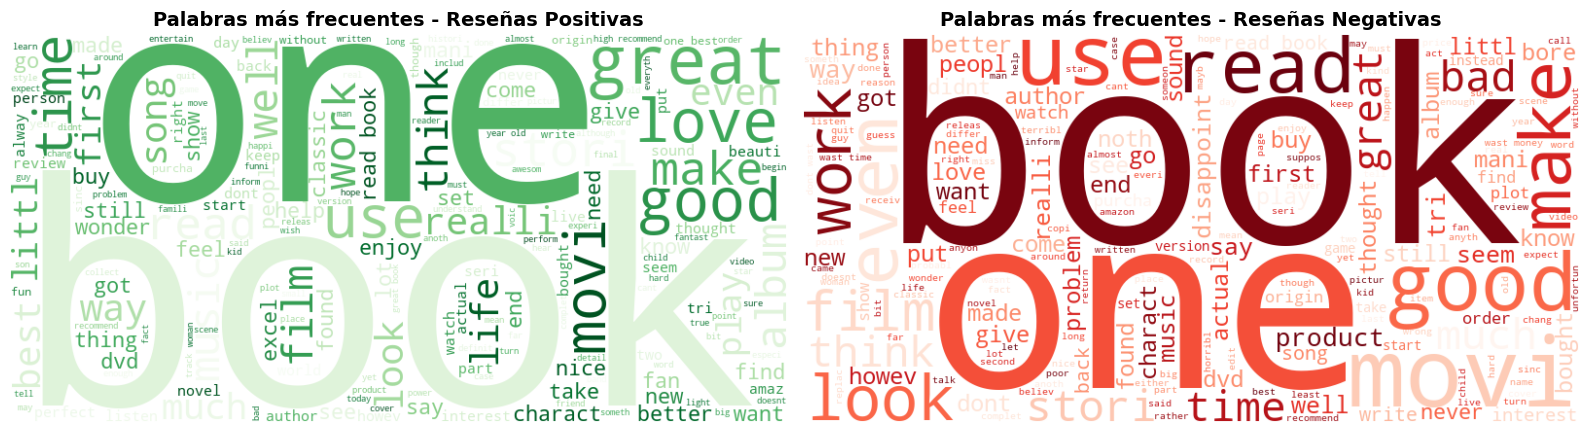

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Crear un DataFrame auxiliar con los textos preprocesados y sus etiquetas
df_cleaned = pd.DataFrame({
    'cleaned_text': x_train_cleaned,
    'sentiment': y_train
})

# Concatenar todos los textos según el sentimiento
texto_positivo = " ".join(df_cleaned[df_cleaned['sentiment'] == 1]['cleaned_text'].astype(str))
texto_negativo = " ".join(df_cleaned[df_cleaned['sentiment'] == 0]['cleaned_text'].astype(str))

# Crear nubes de palabras para ambos sentimientos
wordcloud_pos = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=200
).generate(texto_positivo)

wordcloud_neg = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=200
).generate(texto_negativo)

# Mostrar las nubes de palabras lado a lado
plt.figure(figsize=(16, 8))

# Nube de palabras positivas
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Palabras más frecuentes - Reseñas Positivas", fontsize=14, fontweight='bold')

# Nube de palabras negativas
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Palabras más frecuentes - Reseñas Negativas", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# **6. Entrenamiento de Modelos**

**Naive Bayes:**

*Ventajas:*
- Rápido de entrenar y muy eficiente, incluso con grandes volúmenes de texto.
- Funciona sorprendentemente bien con datos de texto debido a la naturaleza de las palabras y sus frecuencias.
- Excelente como baseline: permite tener un punto de referencia antes de probar modelos más complejos.
- Maneja bien problemas de alta dimensionalidad, como vectores TF-IDF o conteos de palabras.

*Desventajas:*
- La suposición de independencia entre características (palabras) rara vez se cumple en la práctica, lo que puede afectar la precisión.
- Tiende a subestimar la probabilidad de combinaciones de palabras poco frecuentes.
- Puede ser menos preciso que modelos más avanzados cuando el lenguaje es muy contextual o complejo.

**Logistic Regression:**

*Ventajas:*
- Fácil de interpretar: los coeficientes muestran la importancia de cada palabra o característica.
- Buen rendimiento en problemas lineales y como punto de referencia sólido para clasificación binaria.
- Devuelve probabilidades calibradas, lo que permite medir confianza en la predicción.
- Relativamente rápido de entrenar, escalable a datasets medianos.

*Desventajas:*
- Es un modelo lineal, por lo que no captura relaciones complejas o interacciones no lineales entre palabras.
- Puede requerir ingeniería de características adicional si los datos son muy ruidosos o dispersos.
- Sensible a desequilibrio de clases si no se maneja adecuadamente.

**SVM (Support Vector Machine):**

*Ventajas:*
- Muy efectivo en espacios de alta dimensión, como los que generan TF-IDF o embeddings de palabras.
- Capaz de encontrar fronteras de decisión claras, incluso con datos complejos o parcialmente lineales.
- Funciona bien con un número limitado de muestras si las características son informativas.

*Desventajas:*
- Computacionalmente costoso, especialmente en datasets grandes o con muchas características.
- Menos interpretable que modelos lineales; es difícil entender la contribución individual de cada palabra.
- Requiere selección cuidadosa de hiperparámetros y del kernel para obtener un buen rendimiento.

In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import time

# Diccionario de modelos
modelos = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear'),
    "SVM": LinearSVC()
}

# Entrenamiento y almacenamiento de resultados
resultados = {}

# Entrenar cada modelo y medir el tiempo
for nombre, modelo in modelos.items():
    print(f"\nEntrenando {nombre}...")
    inicio = time.time()
    modelo.fit(x_train_tfidf, y_train)
    duracion = time.time() - inicio
    resultados[nombre] = {"modelo": modelo, "tiempo": duracion}
    print(f"{nombre} entrenado en {duracion:.2f} segundos.")

print("\nEntrenamiento completado.")



Entrenando Naive Bayes...
Naive Bayes entrenado en 0.03 segundos.

Entrenando Logistic Regression...
Logistic Regression entrenado en 0.96 segundos.

Entrenando SVM...
SVM entrenado en 1.09 segundos.

Entrenamiento completado.


# **7. Evaluación Detallada**

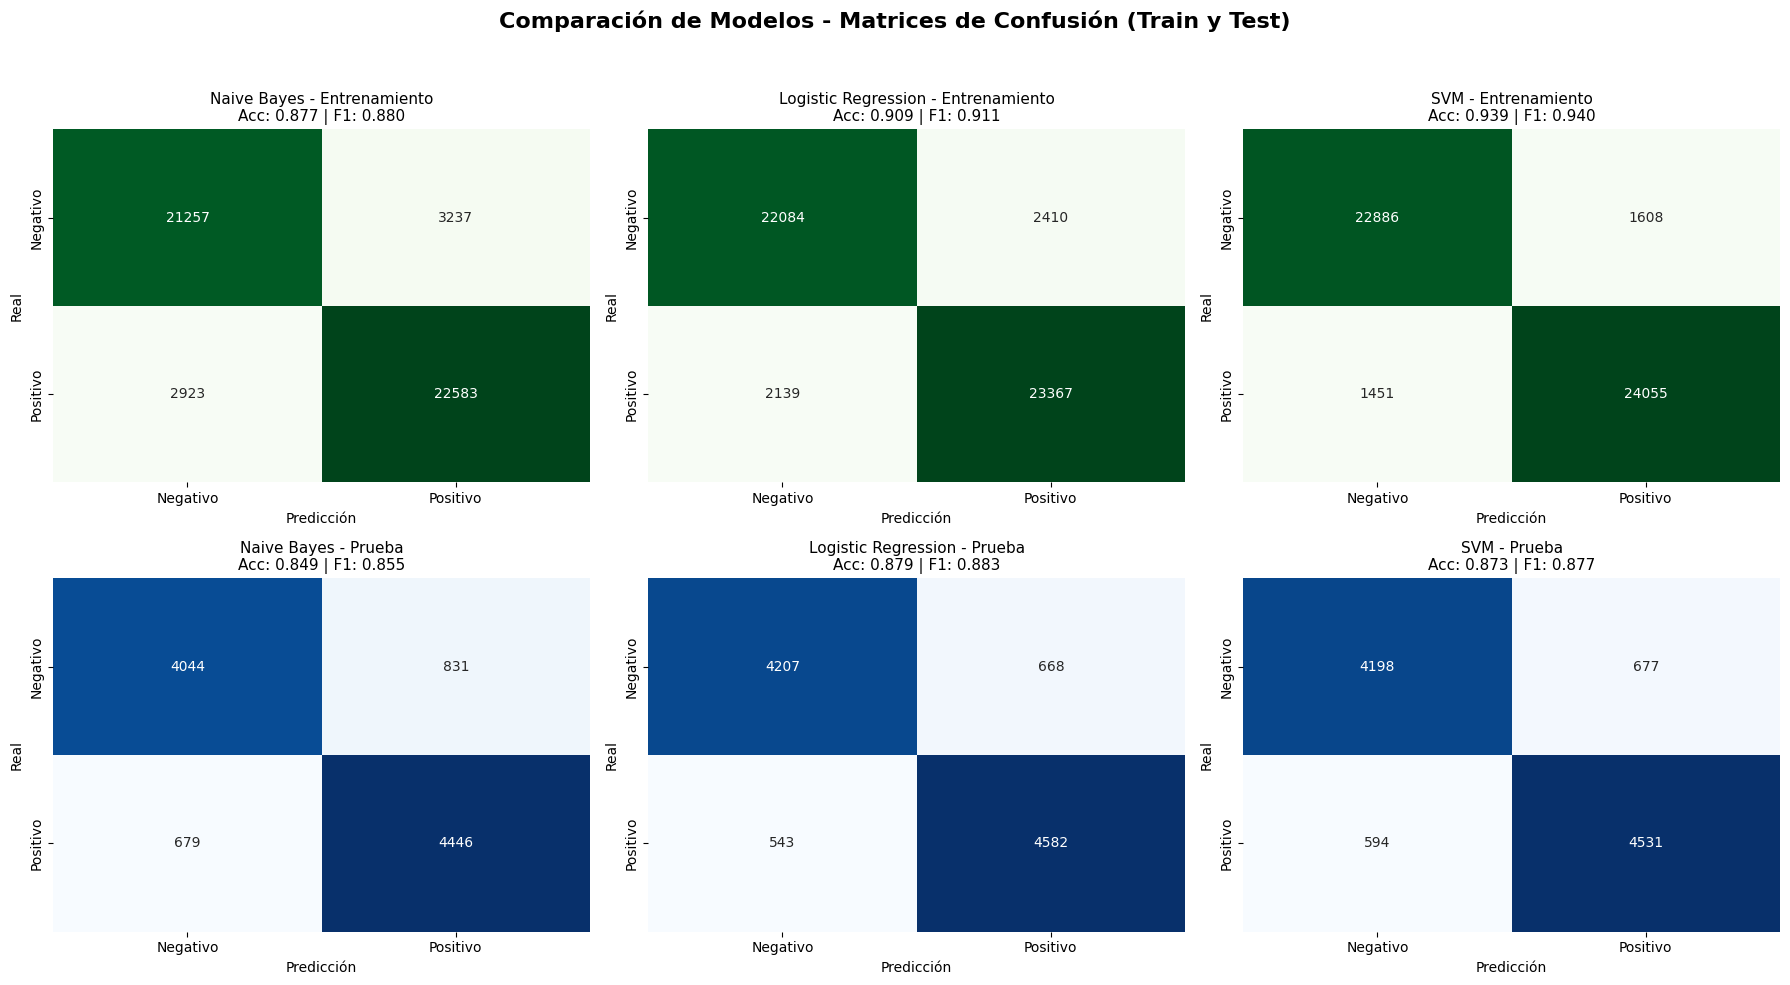


=== RESULTADOS COMPARATIVOS ===


,Modelo,Acc_Train,F1_Train,Acc_Test,F1_Test,Tiempo (s)
0,Naive Bayes,0.876800,0.879983,0.849000,0.854836,0.029760
1,Logistic Regression,0.909020,0.911296,0.878900,0.883277,0.955093
2,SVM,0.938820,0.940218,0.872900,0.876996,1.094908


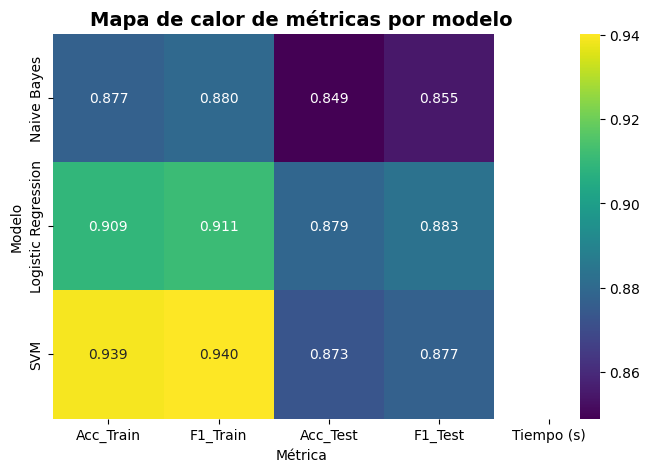

In [24]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Lista para almacenar métricas de cada modelo
metricas = []

# Crear figura para las matrices de confusión
num_modelos = len(resultados)
plt.figure(figsize=(6 * num_modelos, 10))

for i, (nombre, info) in enumerate(resultados.items(), 1):
    modelo = info["modelo"]
    
    # Predicciones
    y_train_pred = modelo.predict(x_train_tfidf)
    y_test_pred = modelo.predict(x_test_tfidf)
    
    # Metricas
    acc_train = accuracy_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred)
    
    metricas.append([
        nombre, 
        acc_train, f1_train, 
        acc_test, f1_test, 
        info["tiempo"]
    ])
    
    # Matriz de confusión: TRAIN
    plt.subplot(2, num_modelos, i)
    cm_train = confusion_matrix(y_train, y_train_pred)
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', cbar=False,
                xticklabels=["Negativo", "Positivo"], yticklabels=["Negativo", "Positivo"])
    plt.title(f"{nombre} - Entrenamiento\nAcc: {acc_train:.3f} | F1: {f1_train:.3f}", fontsize=11)
    plt.xlabel("Predicción")
    plt.ylabel("Real")

    # Matriz de confusión: TEST
    plt.subplot(2, num_modelos, i + num_modelos)
    cm_test = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Negativo", "Positivo"], yticklabels=["Negativo", "Positivo"])
    plt.title(f"{nombre} - Prueba\nAcc: {acc_test:.3f} | F1: {f1_test:.3f}", fontsize=11)
    plt.xlabel("Predicción")
    plt.ylabel("Real")

plt.suptitle("Comparación de Modelos - Matrices de Confusión (Train y Test)", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Tabla comparativa de métricas
df_metricas = pd.DataFrame(metricas, columns=[
    "Modelo", 
    "Acc_Train", "F1_Train", 
    "Acc_Test", "F1_Test", 
    "Tiempo (s)"
])

print("\n=== RESULTADOS COMPARATIVOS ===")
display(df_metricas.style.background_gradient(cmap="viridis", subset=["Acc_Train", "Acc_Test", "F1_Train", "F1_Test"]))

# Guardar la matriz de métricas en una variable numpy para posteriormente analizar si hay overfitting o unnderfitting
matriz_metricas = df_metricas[["Acc_Train", "F1_Train", "Acc_Test", "F1_Test"]].to_numpy()

import seaborn as sns
import matplotlib.pyplot as plt

# Usamos los nombres de las columnas del DataFrame original
columnas = ["Acc_Train", "F1_Train", "Acc_Test", "F1_Test", "Tiempo (s)"]
modelos = df_metricas["Modelo"].tolist()

plt.figure(figsize=(8, 5))
sns.heatmap(matriz_metricas, annot=True, cmap="viridis", xticklabels=columnas, yticklabels=modelos, fmt=".3f")
plt.title("Mapa de calor de métricas por modelo", fontsize=14, fontweight='bold')
plt.xlabel("Métrica")
plt.ylabel("Modelo")
plt.show()


**Comparación visual de métricas (Accuracy y F1-score)** 

En la siguiente gráfica se comparan los valores de *Accuracy* y *F1-score* obtenidos en los conjuntos de entrenamiento y prueba para cada modelo.  
Esto permite identificar rápidamente posibles casos de **overfitting** (gran diferencia entre entrenamiento y prueba), **underfitting** (valores bajos en ambos) o si ambas son similates y altas un buen ajuste.


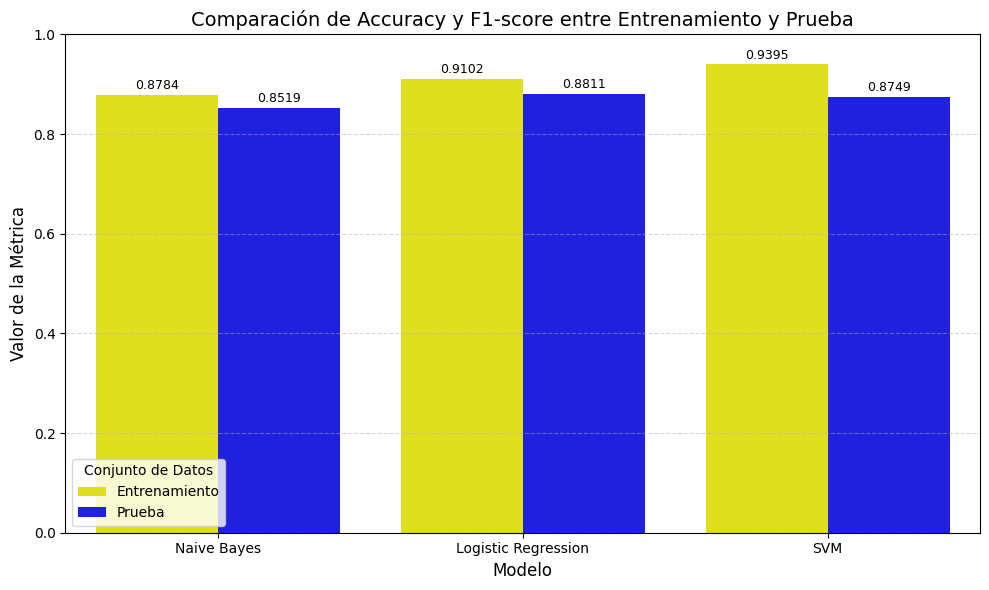

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar datos para la gráfica comparativa
metricas_comparativas = []

# Recopilar métricas de cada modelo
for nombre, info in resultados.items():
    modelo = info["modelo"]

    # Predicciones
    y_train_pred = modelo.predict(x_train_tfidf)
    y_test_pred = modelo.predict(x_test_tfidf)

    # Calcular métricas
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    f1_train = f1_score(y_train, y_train_pred)
    f1_test = f1_score(y_test, y_test_pred)

    # Promedio de ambas métricas (para un gráfico más simple, como el tuyo)
    train_mean = (acc_train + f1_train) / 2
    test_mean = (acc_test + f1_test) / 2

    metricas_comparativas.extend([
        {"Modelo": nombre, "Dataset": "Entrenamiento", "Valor": train_mean},
        {"Modelo": nombre, "Dataset": "Prueba", "Valor": test_mean},
    ])

# Crear DataFrame
df_metricas = pd.DataFrame(metricas_comparativas)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_metricas,
    x="Modelo",
    y="Valor",
    hue="Dataset",
    palette=['yellow', 'blue'],  # tonos similares a la imagen
    errorbar=None
)

plt.title("Comparación de Accuracy y F1-score entre Entrenamiento y Prueba", fontsize=14)
plt.xlabel("Modelo", fontsize=12)
plt.ylabel("Valor de la Métrica", fontsize=12)
plt.ylim(0, 1)
plt.legend(title="Conjunto de Datos")
plt.grid(axis="y", linestyle="--", alpha=0.5)

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", label_type="edge", fontsize=9, padding=2)

plt.tight_layout()
plt.show()


Los tres modelos presentan un comportamiento estable entre entrenamiento y prueba, lo que indica que no existe sobreajuste ni subajuste.

# **8. t-SNE para Visualización**

**PCA (Principal Component Analysis):** lo usamos primero para reducir la dimensionalidad de los datos originales, que probablemente tienen muchísimas características (por ejemplo, cada palabra del TF-IDF). PCA transforma esos datos en un nuevo conjunto de variables, llamadas componentes principales, que capturan la mayor cantidad posible de varianza del dataset. Básicamente nos ayuda a comprimir la información sin perder lo más importante y a que los siguientes algoritmos trabajen más rápido.

**t-SNE (t-distributed Stochastic Neighbor Embedding):** luego aplicamos t-SNE para reducir todavía más los datos y poder visualizarlos mejor. t-SNE no solo reduce dimensiones, sino que también se enfoca en mantener las relaciones locales: puntos que están “cerca” en el espacio original siguen estando cerca en el espacio reducido. Esto es útil para ver si hay grupos o patrones en las reseñas, como clusters de sentimientos positivos o negativos, como es el objetivo del ejercicio planteado.

*PCA hace la reducción inicial y simplifica los datos, y t-SNE organiza esos datos de forma que podamos ver patrones visualmente, aunque los datos estén mezclados y no haya clusters claros.*

In [26]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px

# Selección aleatoria de una muestra del conjunto de prueba para visualización
sample_size = 2000
indices_muestra = np.random.choice(len(y_test), sample_size, replace=False)

x_sample = x_test_tfidf[indices_muestra].toarray()
y_sample = y_test.iloc[indices_muestra].values

# Reducción de dimensionalidad con PCA antes de t-SNE para mejorar rendimiento
pca = PCA(n_components=50, random_state=42)
x_pca = pca.fit_transform(x_sample)

# Aplicar t-SNE para reducción a 2D
tsne_2d = TSNE(
    n_components=2,
    perplexity=20,
    learning_rate=200,
    max_iter=2000,
    random_state=42
)
x_embedded_2d = tsne_2d.fit_transform(x_pca)

# Crear DataFrame para visualización
df_vis_2d = pd.DataFrame({
    "x1": x_embedded_2d[:, 0],
    "x2": x_embedded_2d[:, 1],
    "sentimiento": y_sample
})

# Mapear etiquetas de sentimiento a nombres
df_vis_2d["sentimiento_label"] = df_vis_2d["sentimiento"].map({0: "Negativo", 1: "Positivo"})

# Grafico 2D interactivo con Plotly
fig = px.scatter(
    df_vis_2d,
    x="x1", y="x2",
    color="sentimiento_label",
    color_discrete_map={"Negativo": "red", "Positivo": "green"},
    title="Distribución de Reseñas Amazon (PCA + t-SNE 2D)",
    opacity=0.7,
    height=700,
    width=950
)

fig.update_layout(
    legend_title_text="Sentimiento",
    xaxis_title="t-SNE 1",
    yaxis_title="t-SNE 2",
    plot_bgcolor="white"
)

fig.show()


Como la grafica en 2D implemantada no muestra una separación clara entre las clases, se opta por incluir la visualización en 3D para revisar si hay una mejora significativa en la dimensionalidad adicional.

In [27]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px

# Aplicar t-SNE para reducción a 3D
tsne_3d = TSNE(
    n_components=3,
    perplexity=20,
    learning_rate=200,
    max_iter=2000,
    random_state=42
)
x_embedded_3d = tsne_3d.fit_transform(x_pca)

# Crear DataFrame para visualización
df_vis_3d = pd.DataFrame({
    "x1": x_embedded_3d[:, 0],
    "x2": x_embedded_3d[:, 1],
    "x3": x_embedded_3d[:, 2],
    "sentimiento": y_sample
})

# Mapear etiquetas de sentimiento a nombres
df_vis_3d["sentimiento_label"] = df_vis_3d["sentimiento"].map({0: "Negativo", 1: "Positivo"})

# Grafico 3D interactivo con Plotly
fig = px.scatter_3d(
    df_vis_3d,
    x="x1", y="x2", z="x3",
    color="sentimiento_label",
    color_discrete_map={"Negativo": "red", "Positivo": "green"},
    title="Distribución de Reseñas Amazon (PCA + t-SNE 3D)",
    opacity=0.7,
    size=np.ones(len(df_vis_3d)),  # Tamaño constante
    size_max=10,
    height=700,
    width=950
)

# Forzar uso de símbolos circulares ya que en la grafica inicial los pjuntos negativos son rombos y con un tamaño mayor
fig.update_traces(marker=dict(symbol='circle'))

fig.update_layout(
    legend_title_text="Sentimiento",
    scene=dict(
        xaxis_title="t-SNE 1",
        yaxis_title="t-SNE 2",
        zaxis_title="t-SNE 3"
    )
)

fig.show()


## **PRACTIQUEMOS...**

**Reseñas positivas**
- "This product exceeded my expectations, very happy with the purchase!"
- "Excellent quality and fast shipping. Highly recommend."
- "I love it! Works perfectly and looks great."
- "Five stars! Definitely worth the price."
- "Amazing customer service and very reliable product."
- "Exactly as described, couldn’t be happier."
- "Great value for money, will buy again."
- "The product is sturdy and works as advertised."
- "Superb! Arrived early and works flawlessly."
- "Very satisfied with this purchase. Highly recommended."

**Reseñas negativas**
- "Terrible experience, the product broke after one use."
- "Not worth the money, very disappointed."
- "Arrived late and in poor condition."
- "Low quality and doesn’t match the description."
- "I regret buying this, it’s useless."
- "The item stopped working within a week."
- "Customer service was unhelpful and rude."
- "Very flimsy and cheaply made, avoid it."
- "Not as advertised, completely misleading."
- "I would give zero stars if I could."

In [33]:
import pandas as pd

# Diccionario de etiquetas
etiquetas = {0: "Negativa", 1: "Positiva"}

# Ingreso de la frase a evaluar
frase = "Low quality and doesn’t match the description."

# Preprocesar usando la misma función que se usó en entrenamiento
frase_preprocesada = preprocesar_texto_para_modelo(frase)

# Vectorizar la frase con el TF-IDF entrenado
frase_tfidf = tfidf_vectorizer.transform([frase_preprocesada])

# Crear un DataFrame para mostrar resultados
predicciones = []

for nombre, info in resultados.items():
    modelo = info["modelo"]
    pred = modelo.predict(frase_tfidf)[0]
    predicciones.append([nombre, etiquetas[pred]])

# Mostrar resultados
df_pred = pd.DataFrame(predicciones, columns=["Modelo", "Clasificación"])
print("\n=== RESULTADOS DE CLASIFICACIÓN ===")
print(df_pred.to_string(index=False))



=== RESULTADOS DE CLASIFICACIÓN ===
             Modelo Clasificación
        Naive Bayes      Negativa
Logistic Regression      Negativa
                SVM      Negativa


## **Conclusiones**

- Al inicio, se pensó que estábamos desarrollando el proceso de manera incorrecta, ya que no se observaba una separación clara entre los clusters: las reseñas positivas y negativas están muy mezcladas. Esto también se evidencia en las nubes de palabras, donde se repiten términos en ambos tipos de reseñas, lo que confirma que el dataset contiene información muy mezclada y que el desafío principal es que los modelos aprendan a diferenciar patrones sutiles en el texto. Revisando trabajos y páginas que han desarrollado procesos similares con la BD de Kaggle, pudimos notar que su comportamiento es muy parecido al nuestro, y también concluyen que la información de ambos sentimientos está mezclada.
- Se identifica que en el proceso no hay ni overfitting, ni underfitting. Hay un buen ajuste en los modelos.
- El modelo con mejor desempeño fue Logistic Regression, alcanzando un accuracy de 0.8789 (87,89%), seguido de SVM con 0.8729 (87,29%). Esto demuestra que, aunque los datos no presenten clusters claros, estos modelos pueden capturar patrones significativos y diferenciar correctamente la mayoría de las reseñas.
- Por último, la visualización mediante t-SNE en 2D y 3D confirmó que no existen clusters claramente diferenciados, pero sigue siendo útil para explorar la distribución de los datos y detectar patrones o anomalías.
- En el bloque PRACTIQUEMOS…, verificamos que los modelos funcionan correctamente incluso con frases nuevas ingresadas manualmente. Esto se evidenció principalmente en los modelos con mayor accuracy, LR y SVM, que lograron predecir de manera consistente el sentimiento de las reseñas.

**Conclusión general:** A pesar de la alta mezcla de información en el dataset, los modelos entrenados son capaces de generalizar y reconocer patrones de manera efectiva, siendo Logistic Regression y SVM las mejores opciones para este problema de clasificación de sentimientos.